
# First Step into Quantum Computing

- Difficulties: Beginner
- QPU time usage: about 5 s (section 5) + about 30 s (optional section 6)

Welcome, hackers! We're thrilled to have you for the workshop. The main goal of this introductory hands-on is to make you ready for your quantum journey by 1) guiding you how to install qiskit 2) how to create IBM Cloud account and prepare `api_key` and `crn` to use a real quantum computer and 3) make your first quantum circuit, 4) solve a quantum state quiz, 5) run your circuits on a real quantum computer, see what the transpiler did to them, and plot the result, and 6) watch error mitigation take some of the noise back out.


> **Workshop edition.** Adapted for the *Introduction to Qiskit* hands-on session (2026-09-24) from the original **First Step into Quantum Computing** notebook by **Sophy Shin** (reviewed by Nate Earnest-Noble), (C) IBM Corp. 2025, Apache-2.0. Changes: account cells for `qiskit-ibm-runtime` 0.49; predict-then-run prompts in sections 3-4; section 5 as the four [Qiskit pattern](https://quantum.cloud.ibm.com/docs/guides/intro-to-patterns) steps, run **hardware-first** (a local `FakeFez` simulator only if the connection fails) with an original-vs-transpiled drawing; section 6 on error mitigation.

**What you will take away**
1. Single- and multi-qubit gates, read off a QSphere instead of an equation.
2. The four-step Qiskit pattern, applied to nine tiny circuits.
3. What a real QPU adds to a state you designed: noise - and what error mitigation takes back.

## 1. First things first: Qiskit

### What is Qiskit


The **[Qiskit SDK](https://www.ibm.com/quantum/qiskit)** is a high performance software stack built to help developers and researchers harness the full power of quantum computers at the utility scale and beyond. At its core is the Qiskit SDK, an open source software development kit for working with quantum computers at the level of extended quantum circuits. Operators and primitives. The Qiskit SDK allows anyone to get optimal performance from real quantum computers using their preferred computing environment. 

Beyond the SDK, Qiskit also includes a suite of high performance tools and services like [IBM Quantum Compute service (formerly Qiskit Runtime)](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/runtime-service), which enables optimized computations at IBM quantum computers through the cloud using primitives that manage error mitigation. The Qiskit Transpiler service, which provides state of the art heuristic and AI powered methods that boost performance for common quantum circuit optimization tasks. 

[Qiskit functions](https://quantum.cloud.ibm.com/docs/en/guides/functions), a catalog of IBM and third party services that make it easy to optimize workloads and leverage Qiskit for industry use cases. Whether you're a quantum software developer, a quantum experimentalist, a computational scientist, or just looking to get started Qiskit’s modular, flexible framework lets you work at the abstraction level that best suits your needs. 

Qiskit is designed for extensibility and customization, so you can extract industry leading performance and tackle new kinds of problems. A high performance code base means a Qiskit SDK works faster, uses less memory, and delivers better results than ever before. And Qiskit also introduces you to a vast community of users and developers who are eager to welcome you and help answer your questions. First launched in 2019, [the Qiskit advocate program](https://www.ibm.com/quantum/qiskit#advocates) is a global, community-centered initiative that recruits quantum computing professionals and enthusiasts from all over the world. Over the years, advocates have gone on to become recognized leaders in the quantum community. Want to be a next quantum leader? Don't hesitate to apply - [here](https://airtable.com/app8koO4BZifGFhCV/pagJvJphu4PBNkuE7/form)

### Install Qiskit

First, check that the version of Python you are using in your environment is python>=3.10, to make sure that it is compatible with the latest Qiskit version we will use

``` python
from platform import python_version

print(python_version())
```
If that is not the case, you can upgrade it using your preferred tool. If you are unsure how to do it, some recommended options are:

- MacOS: [Homebrew](https://brew.sh/)
- Linux: `sudo apt-get update `

A detailed guide on how to upgrade Python depending on your OS is detailed here: [How to update Python](https://4geeks.com/how-to/how-to-update-python-version)


For more information take a look at the QGSS(Qiskit Global Summer School) 2025 wiki: https://github.com/qiskit-community/qgss-2025/wiki/Jupyter-Notebook-Environment-(Local-and-Online)

You can verify your installation by running the cell below. If you installed correctly, it will return the qiskit version.

In [ ]:
# Packages come from the pre-work email / 00_setup_check.ipynb. Uncomment ONLY if 00_setup_check failed
# (running pip mid-workshop changes your environment):
# %pip install 'qiskit[visualization]'
# %pip install qiskit-ibm-runtime
# %pip install qiskit-aer


In [ ]:
import qiskit

print(f"Qiskit version: {qiskit.__version__}")

### Troubleshooting

If the previous cell raised an error, you can opt to install Qiskit in a virtual environment (two suggested methods follow). If you have no errors, you can ignore this cell and proceed to the next one.

Here we propose two different methods to set up a virtual environment to install Qiskit.
1. Using [venv](https://docs.python.org/3/library/venv.html), as explained in the [Qiskit installation guide](https://quantum.cloud.ibm.com/docs/guides/install-qiskit). 
2. Using [conda](https://docs.conda.io/projects/conda/en/latest/user-guide/install/index.html), as explained in this video of [Coding with Qiskit](https://www.youtube.com/watch?v=93-zLTppFZw&list=PLOFEBzvs-VvrgHZt3exM_NNiNKtZlHvZi&index=4).

## 2. Set up your IBM Cloud account <a id="setting-ibm-cloud"></a>

To use a real quantum computer, you need an `api key` - a main entrance ticket to the cloud and a `crn` - token that will bring your resources to you by setting your account.

Set up your account as follows:

1. Go to the [IBM Quantum&reg; Platform](https://quantum.cloud.ibm.com/).
2. Go to the top right corner (as shown in the above picture), create your API token, and copy it to a secure location.
3. In the next cell, replace `deleteThisAndPasteYourAPIKeyHere` with your API key.
4. Check the account and region switcher at the top of the page and make sure the **us-east** region is selected — the Open Plan is only available in the us-east region, and you can only see instances created in the region you are logged in to.
5. Go to the bottom left corner (as shown in the above picture) and **create your instance**. Make sure to choose the open plan.
6. After the instance is created, copy its associated CRN code. You may need to refresh to see the instance.
7. In the cell below, replace `deleteThisAndPasteYourCRNHere` with your CRN code.

See [this guide](https://quantum.cloud.ibm.com/docs/guides/cloud-setup) for more details on how to set up your IBM Cloud&reg; account.

**No account yet, or the connection fails?** Skip the key cell. The notebook then falls back to a local simulator of `ibm_fez` automatically, and everything below still runs - re-run the connection cell later, then section 5 from Step 2, to switch to the real machine.

<div class="alert alert-block alert-warning">
    
⚠️ **Note:** Treat your API key as you would a secure password. See the [Cloud setup](https://quantum.cloud.ibm.com/docs/guides/cloud-setup#cloud-save) guide for more information about using your API key in both secure and untrusted environments.

Additionally, if you are a member of the IBM partner network university, please use your institution's email address for your IBM ID to receive the partner benefit. 
</div>


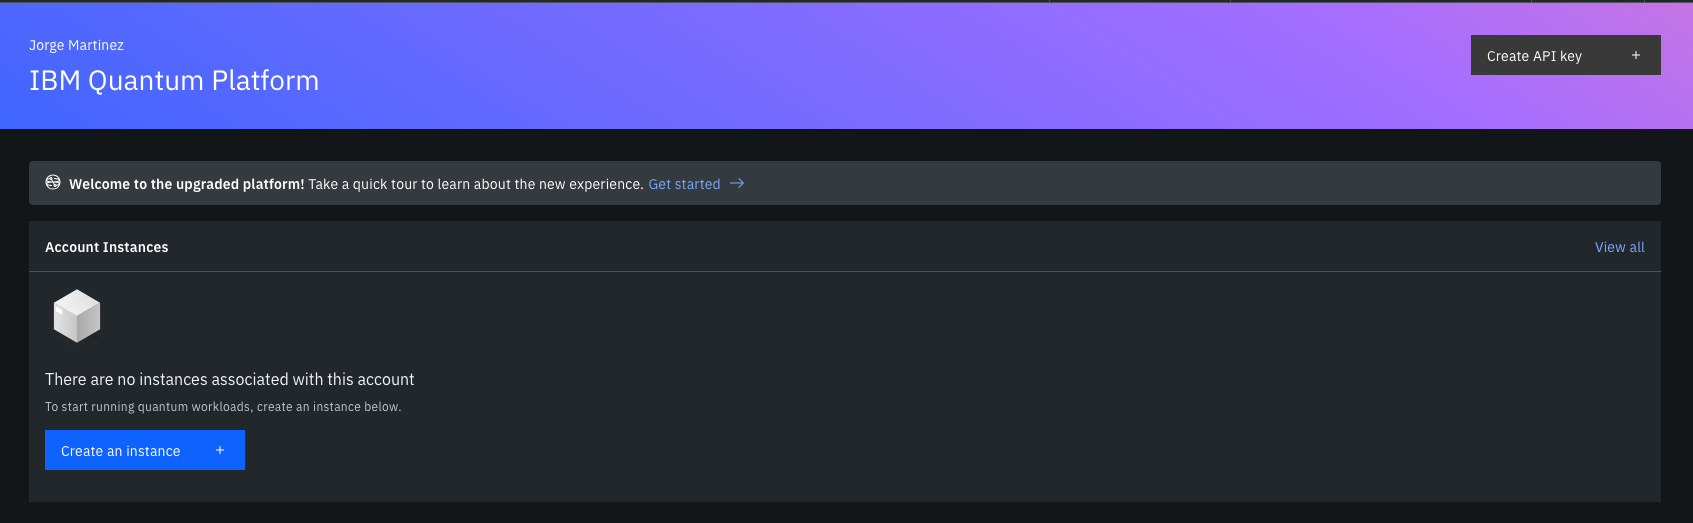




In [ ]:
# Run this cell ONCE with your own key and CRN. Already saved them in 00_setup_check, or no account yet? Skip it.
from qiskit_ibm_runtime import QiskitRuntimeService

your_api_key = "deleteThisAndPasteYourAPIKeyHere"
your_crn = "deleteThisAndPasteYourCRNHere"        # the CRN of your Open Plan instance

if "delete" not in your_api_key + your_crn:
    QiskitRuntimeService.save_account(token=your_api_key, instance=your_crn, set_as_default=True, overwrite=True)
    print("Credentials saved.")
else:
    print("Nothing saved - paste your key and CRN above, or skip this cell.")

# Docs: https://quantum.cloud.ibm.com/docs/guides/save-credentials

In [ ]:
# Connect to IBM Quantum and pick the least busy QPU.
# If that fails (no account yet, no network), fall back to a local simulator of ibm_fez.
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeFez

try:
    service = QiskitRuntimeService()
    for b in service.backends():
        print(f"{b.name:16s} {b.num_qubits} qubits, {b.status().pending_jobs} jobs in queue")
    backend = service.least_busy(operational=True, simulator=False)
except Exception as err:
    print("Could not connect to IBM Quantum ->", err)
    backend = FakeFez()

print("\nbackend for this notebook:", backend.name)

## 3. Your first Quantum Circuit

### Quantum circuits

The fundamental unit of Qiskit is the **quantum circuit**, which is a series of instructions that a quantum computer can use to work with quantum bits of information, also known as **qubits**. These qubits have special properties that enable quantum computers to approach problems differently than how your laptop or iPhone might. Qiskit is rapidly advancing as a technology -- while you can still manually design your quantum circuits and decide how you want it to run (and there are plenty of good reasons to do so), IBM Quantum also provides you with tools that simplify the process. For the sake of learning, we are going to design a few very simple circuits and, in section 5, run them on a real quantum computer.

We're breezing through this overview because, honestly, we could spend hours just explaining the basics of quantum information and computation. In fact, IBM Quantum has done this already, producing a [written course](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/introduction) and a series of [video lectures](https://www.youtube.com/playlist?list=PLOFEBzvs-VvqKKMXX4vbi4EB1uaErFMSO) devoted to the topic. If you need a refresher, check them out!

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import array_to_latex
from qiskit.visualization import plot_distribution

import numpy as np
from numpy import sqrt

### Basic Operations on Qubits and Measurements

### Writing down single-qubit states
Let us start by looking at a single qubit. The main difference between a classical bit, which can take the values 0 and 1 only, is that a quantum bit, or **qubit**, can be in the states $\vert0\rangle$, $\vert1\rangle$, as well as a linear combination of these two states. This feature is known as superposition, and allows us to write the most general state of a qubit as: 

$$\vert\psi\rangle = \sqrt{1-p}\vert0\rangle + e^{i \phi} \sqrt{p}  \vert1\rangle$$

If we were to measure the state of this qubit, we would find the result $1$ with probability $p$, and the result $0$ with probability $1-p$. As you can see, the total probability is $1$, meaning that we will indeed measure either $0$ or $1$, and no other outcomes exists.

In addition to $p$, you might have noticed another parameter above. The variable $\phi$ indicates the relative quantum phase between the two states $\vert0\rangle$ and $\vert1\rangle$. As we will discover later, this relative phase is quite important. For now, it suffices to note that the quantum phase is what enables interference between quantum states, resulting in our ability to write quantum algorithms for solving specific tasks.


### Visualizing quantum states
We visualize quantum states throughout this exercise using what is known as a `qsphere`. Here is how the `qsphere` looks for the states $\vert0\rangle$ and $\vert1\rangle$, respectively. Note that the top-most part of the sphere represents the state $\vert0\rangle$, while the bottom represents $\vert1\rangle$.


In [ ]:
#visualize |0>
sv=Statevector([1, 0])
plot_state_qsphere(sv)

You can make the exactly same QSphere by using a quantum circuit. The statevector here we uses is from $|0\rangle$ state. In Qiskit, the qubit is initialized in $|0\rangle$ state. Try to run below circuit and see if you can get the same QSphere.

In [ ]:
qc1 = QuantumCircuit(1)
sv=Statevector(qc1)
plot_state_qsphere(sv)

Now let's visualize $|1\rangle$ State. 

It should be no surprise that the superposition state with quantum phase $\phi = 0$ and probability $p = 1/2$ (meaning an equal likelihood of measuring both 0 and 1) is shown on the `qsphere` with two points. However, note also that the size of the circles at the two points is smaller than when we had simply $\vert0\rangle$ and $\vert1\rangle$ above. This is because the size of the circles is proportional to the probability of measuring each one, which is now reduced by half.


In [ ]:
#visualize 1/sqrt(2)|0> + 1/sqrt(2)|1>

sv=Statevector([1/sqrt(2), 1/sqrt(2)])
plot_state_qsphere(sv)

In the case of superposition states, where the quantum phase is non-zero, the qsphere allows us to visualize that phase by changing the color of the respective blob. For example, the state with $\phi = 90^\circ$ (degrees) and probability $p = 1/2$ is shown in the `qsphere` below. 


In [ ]:
sv=Statevector([1/sqrt(2), 1/sqrt(2)*1j])
plot_state_qsphere(sv)

### Manipulating qubits
Qubits are manipulated by applying quantum gates. Let's go through an overview of the different gates that we will consider in the following exercises.

First, let's describe how we can change the value of $p$ for our general quantum state. To do this, we will use two gates:

1. **$X$-gate**: This gate flips between the two states $\vert0\rangle$ and $\vert1\rangle$. This operation is the same as the classical NOT gate. As a result, the $X$-gate is sometimes referred to as a bit flip or NOT gate. Mathematically, the $X$ gate changes $p$ to $1-p$, so in particular from 0 to 1, and vice versa.

2. **$H$-gate**: This gate allows us to go from the state $\vert0\rangle$  to the state $\frac{1}{\sqrt{2}}\left(\vert0\rangle + \vert1\rangle\right)$. This state is also known as the $\vert+\rangle$. Mathematically, this means going from $p=0, \phi=0$ to  $p=1/2, \phi=0$.  As the final state of the qubit is a superposition of $\vert0\rangle$ and $\vert1\rangle$, the Hadamard gate represents a true quantum operation.


Notice that both gates changed the value of $p$, but not $\phi$. Fortunately for us, it's quite easy to visualize the action of these gates by looking at the figure below.


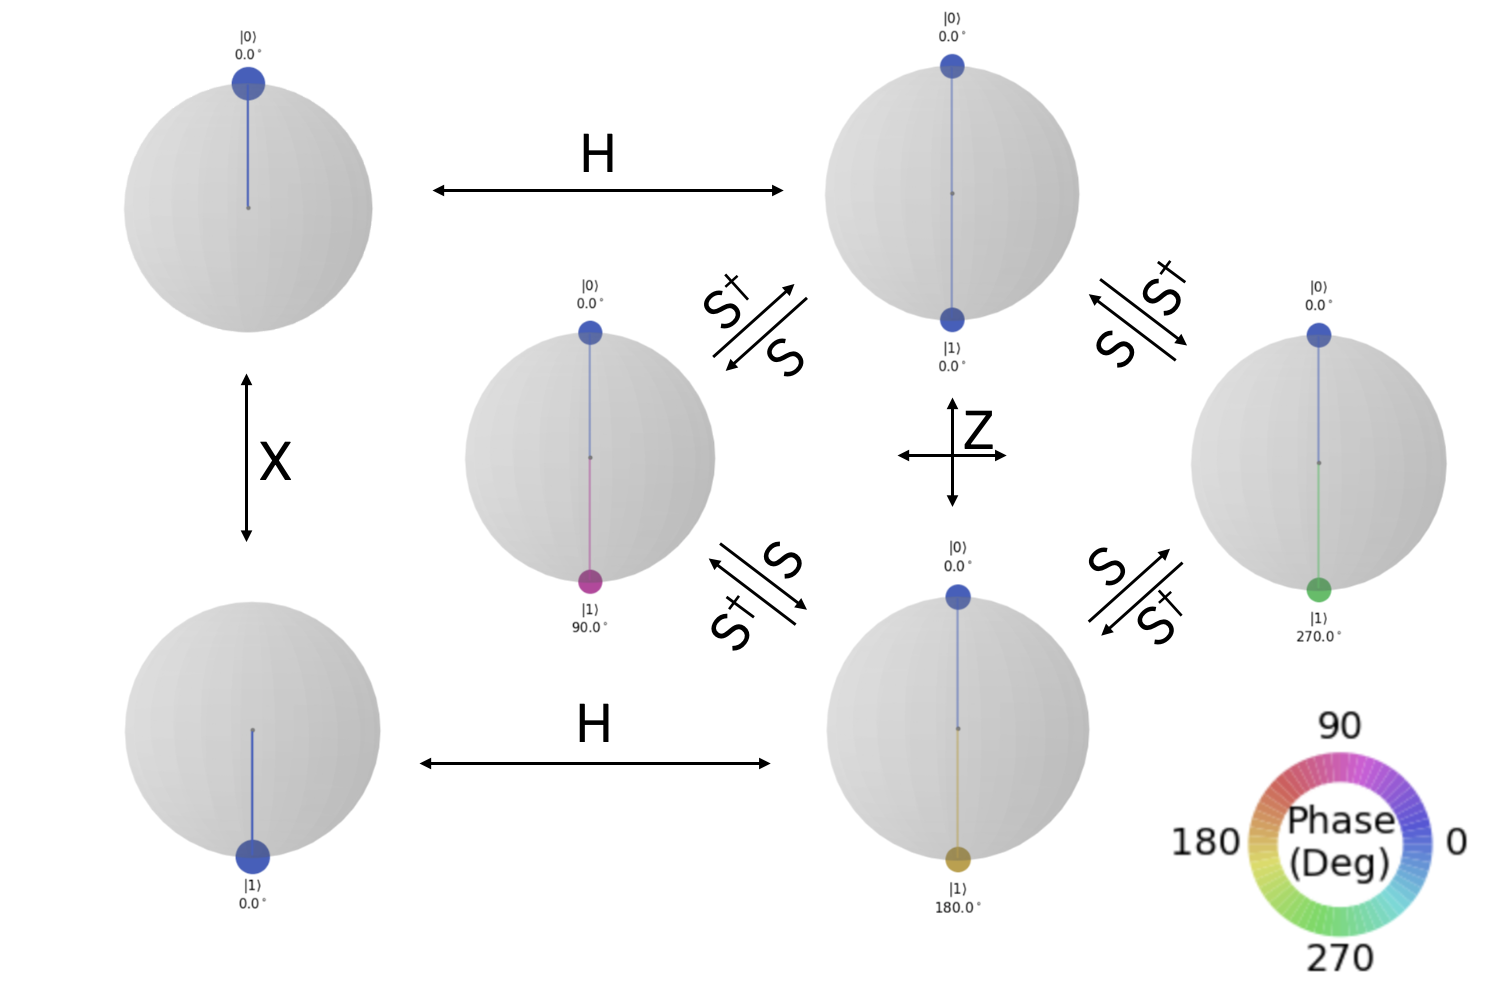

Once we have the state $\vert+\rangle$, we can then change the quantum phase by applying several other gates. For example, an $S$ gate adds a phase of $90$ degrees to $\phi$, while the $Z$ gate adds a phase of $180$ degrees to $\phi$. To subtract a phase of $90$ degrees, we can apply the $S^\dagger$ gate, which is read as S-dagger, and commonly written as `sdg`. Finally, there is a $Y$ gate which applies a sequence of $Z$ and $X$ gates.

You can experiment with the gates $X$, $Y$, $Z$, $H$, $S$ and $S^\dagger$ to become accustomed to the different operations and how they affect the state of a qubit. To do so, you can visit [Circuit Composer](https://quantum.cloud.ibm.com/composer) and start our circuit widget. After visiting the circuit composer, choose a gate to apply to a qubit, and then choose the qubit (in the first examples, the only qubit to choose is qubit 0).  Watch how the corresponding state changes with each gate, as well as the description of that state. It will also provide you with the code that creates the corresponding quantum circuit in Qiskit.

If you want to learn more about describing quantum states, Pauli operators, and other single-qubit gates, see [Quantum Information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/quantum-information) of the Single System of the [Basics of Quantum Information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information) Course by John Watrous. 

### Practices:  Quantum Circuits Using Single-Qubit Gates

Here are four small practices to attain different states on the qsphere. You can either solve them with the circuit composer and copy and paste the code it provides into the respective cells to create the quantum circuits, or you can directly insert a combination of the following code lines into the program to apply the different gates: 

    qc.x(0)    # bit flip
    qc.y(0)    # bit and phase flip
    qc.z(0)    # phase flip
    qc.h(0)    # superpostion
    qc.s(0)    # quantum phase rotation by pi/2 (90 degrees)
    qc.sdg(0)  # quantum phase rotation by -pi/2 (90 degrees)
    
The '(0)' indicates that we apply this gate to qubit 'q0', which is the first (and in this case only) qubit.

Try to attain the given state on the qsphere in each of the following exercises.

#### i) Let us start  by performing a bit flip. The goal is to reach the state $\vert1\rangle$ starting from state $\vert0\rangle$. 


### Predict-then-run scoreboard

From here on, **predict first**. Before you run a cell, sketch the QSphere (which basis states light up,
and with what phase) or the histogram (which bit strings dominate) that you expect.

**Scoring: 1 point for every cell where you correctly named the dominant outcome(s) before running it.**
Nine circuits, eight points: `qc1` (the $\vert0\rangle$ state you built above) is the worked example;
`qc2` to `qc9` are yours to call. Write your guesses down - "I knew that" after the fact does not count.


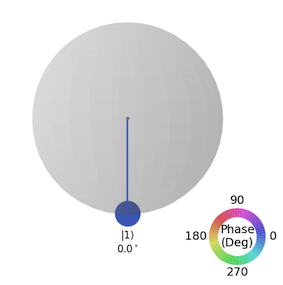

> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:

def create_circuit():
    qc = QuantumCircuit(1)
    #
    #
    # FILL YOUR CODE IN HERE
    #
    #
    return qc

# check solution
qc2 = create_circuit()
state = Statevector(qc2)

plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True) 

#### ii) Next, let's create a superposition. The goal is to reach the state $|+\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + |1\rangle\right)$. 

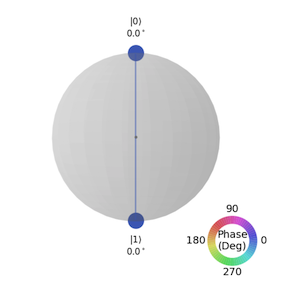

> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:

def create_circuit2():
    qc = QuantumCircuit(1)
    #
    #
    # FILL YOUR CODE IN HERE
    #
    #
    return qc

qc3 = create_circuit2()
state = Statevector(qc3)
plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True) 

#### iii) Let's combine those two. The goal is to reach the state $|-\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle - |1\rangle\right)$. 

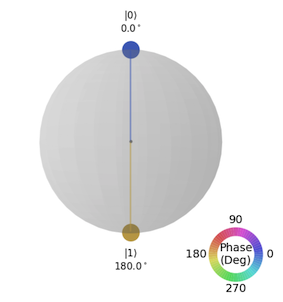

Can you combine the above two tasks to come up with the solution?

> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:
def create_circuit3():
    qc = QuantumCircuit(1)
    #
    #
    # FILL YOUR CODE IN HERE
    #
    #
    return qc

qc4 = create_circuit3()
state = Statevector(qc4)
plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True) 

#### iv) Finally, we move on to the complex numbers. The goal is to reach the state $|\circlearrowleft\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle - i|1\rangle\right)$

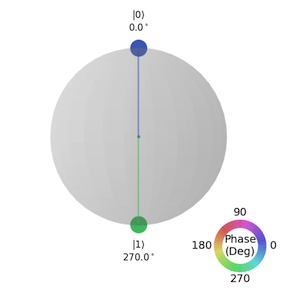

> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:
def create_circuit4():
    qc = QuantumCircuit(1)
    #
    #
    # FILL YOUR CODE IN HERE
    #
    #
    return qc

qc5 = create_circuit4()
state = Statevector(qc5)

plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True) 

## 4. Quantum Quiz with Multi-Qubit Gates

Great job! Now that you've understood the single-qubit gates, let us look at gates operating on multiple qubits. Here you will be asked to solve 4 quantum state quizzes by combining single-qubit gates and multi-qubit gates. The basic gates on two qubits are given by

    qc.cx(c,t)       # controlled-X (= CNOT) gate with control qubit c and target qubit t
    qc.cz(c,t)       # controlled-Z gate with control qubit c and target qubit t
    qc.swap(a,b)     # SWAP gate that swaps the states of qubit a and qubit b

If you'd like to read more about the different multi-qubit gates and their relations, visit [Quantum Information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/quantum-information) of multiple systems, of John's `Basics of Quantum Information` Course.

Note that for two qubits a general state is of the form $a|00\rangle + b |01\rangle + c |10\rangle + d|11\rangle$, where $a$, $b$, $c$, and $d$ are complex numbers whose absolute values squared give the probability to measure the respective state; e.g., $|a|^2$ would be the probability to end in state '0' on both qubits. This means we can now have up to four points on the qsphere.

We start with the canonical two qubit gate, the controlled-NOT (also CNOT or CX) gate.  Here, as with all controlled two qubit gates, one qubit is labelled as the "control", while the other is called the "target". If the control qubit is in state $|0\rangle$, it applies the identity $I$ gate to the target, i.e., no operation is performed. Instead, if the control qubit is in state $|1\rangle$, an X-gate is performed on the target qubit. Therefore, with both qubits in one of the two classical states, $|0\rangle$ or $|1\rangle$, the CNOT gate is limited to classical operations.

This situation changes dramatically when we first apply a Hadamard gate to the control qubit, bringing it into the superposition state $|+\rangle$.  The action of a CNOT gate on this non-classical input can produce highly entangled states between control and target qubits. If the target qubit is initially in the $|0\rangle$ state, the resulting state is denoted by $|\Phi^+\rangle$, and is one of the so-called [Bell states](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/quantum-information#bell-states). 

#### i) Construct the Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right)$.  

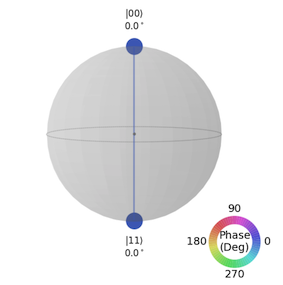


For this state we would have probability $\frac{1}{2}$ to measure "00" and probability $\frac{1}{2}$ to measure "11". Thus, the outcomes of both qubits are perfectly correlated.

> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:

def create_circuit5():
    qc = QuantumCircuit(2)
    #
    #
    # FILL YOUR CODE IN HERE
    #
    #
    return qc

qc6 = create_circuit5()
state = Statevector(qc6) # determine final state after running the circuit
display(array_to_latex(state))
display(plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True))
qc6.draw(output='mpl') # we draw the circuit

Next, try to create the state of perfectly anti-correlated qubits. Note the minus sign here, which indicates the relative phase between the two states. 

#### ii) Construct the Bell state $\vert\Psi^-\rangle = \frac{1}{\sqrt{2}}\left(\vert01\rangle - \vert10\rangle\right)$.



> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:


def create_circuit6():
    qc = QuantumCircuit(2)
    #
    #
    # FILL YOUR CODE IN HERE
    #
    #
    return qc

qc7 = create_circuit6()
state = Statevector(qc7) # determine final state after running the circuit
display(array_to_latex(state))
display(plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True))
qc7.draw(output='mpl') # we draw the circuit

### iii) You are given the quantum circuit described in the function below. Swap the states of the first and the second qubit to get this QSphere.

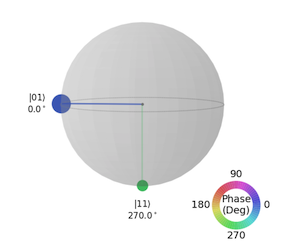

> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:
def create_circuit7():
    qc = QuantumCircuit(2)
    qc.rx(np.pi/3,0)
    qc.x(1)
    return qc

qc8 = create_circuit7()

#
#
# FILL YOUR CODE IN HERE
#
#


state = Statevector(qc8) # determine final state after running the circuit
display(array_to_latex(state))
display(plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True))
qc8.draw(output='mpl') # we draw the circuit

#### iv) Write a program from scratch that creates the GHZ state (on three qubits), $\vert \text{GHZ}\rangle = \frac{1}{\sqrt{2}} \left(|000\rangle + |111 \rangle \right)$

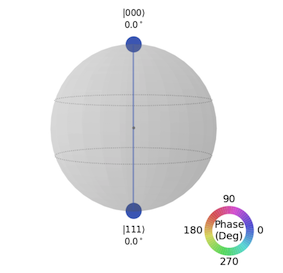

> **Predict first.** Sketch the QSphere / histogram you expect *before* running the next cell.
> Which basis states have non-zero amplitude? Equal weights or not? Any relative phase?
> Score 1 point if the dominant outcome(s) you named come out right.


In [ ]:

def create_circuit8():
    qc = QuantumCircuit(3)
    #
    #
    # FILL YOUR CODE IN HERE
    #
    #
    return qc

qc9 = create_circuit8()


state = Statevector(qc9) # determine final state after running the circuit
display(array_to_latex(state))
display(plot_state_qsphere(state, show_state_labels=True, show_state_phases = True, use_degrees = True))
qc9.draw(output='mpl') # we draw the circuit


## 5. Run your circuits on a real quantum computer

Time for the exciting part: running the nine circuits and looking at the measured bit strings. We follow the four steps of a [Qiskit pattern](https://quantum.cloud.ibm.com/docs/guides/intro-to-patterns):

1. **Map** the problem to quantum circuits and operators
2. **Optimize** the circuits for the target hardware
3. **Execute** on the hardware with a primitive
4. **Post-process** the results

`backend` comes from section 2: a real QPU, or the local `FakeFez` stand-in if you could not connect. The code is the same either way.

### Step 1 - Map

*Map the problem to quantum circuits and operators.*

This step is already done: `qc1` ... `qc9` from sections 3 and 4 **are** the mapping. Nine states,
nine circuits. Keep this label in mind - the QAOA demo later does exactly the same step, only the
"problem" there is a 100-node graph instead of a picture of a QSphere.


### Step 2 - Optimize

*Optimize the circuits for the target hardware.*

A QPU knows only a handful of native gates, and its qubits are not all connected. The **pass manager** rewrites each circuit into that instruction set (an *ISA circuit*) and places it on physical qubits. `optimization_level` goes from 0 (just translate) to 3 (most aggressive).

In [ ]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

circuits = [qc1, qc2, qc3, qc4, qc5, qc6, qc7, qc8, qc9]
isa_circuits = [pm.run(qc.measure_all(inplace=False)) for qc in circuits]   # add measurements, then transpile

print("backend:", backend.name)
print("ISA circuit depths:", [c.depth() for c in isa_circuits])

#### What did the transpiler do?

Same GHZ state, two very different circuits. Before: your `h` and `cx` gates on qubits 0, 1, 2. After: only the backend's native gates, on the physical qubits the pass manager chose (a label like `q0 ↦ 102` means your qubit 0 lives on physical qubit 102 - your number will differ). The depth grows, but every gate is now one the machine can actually play.

In [ ]:
ghz = qc9.measure_all(inplace=False)

print("before:", dict(ghz.count_ops()), "| depth", ghz.depth())
print("after: ", dict(isa_circuits[8].count_ops()), "| depth", isa_circuits[8].depth())

display(ghz.draw("mpl"))
isa_circuits[8].draw("mpl", idle_wires=False)

### Step 3 - Execute

*Execute on the target hardware.*

`Sampler` returns measurement counts (`Estimator`, used in section 6, returns expectation values). One `sampler.run(...)` call submits all nine circuits as a single job. **Note the `job_id`**: on a busy day your job waits in a queue, and the id lets you fetch the result later without re-running anything.

In [ ]:
sampler = Sampler(mode=backend)
job = sampler.run(isa_circuits, shots=1024)

print("job_id:", job.job_id())
print("status:", job.status())

### Step 4 - Post-process

*Post-process the results.*

`job.result()` waits for the job to finish. `result[k].data.meas.get_counts()` gives the counts of circuit `k` (the register `measure_all()` created is called `meas`). Then we plot the nine distributions in four groups. Queue too long? Interrupt (■) and use the lecturer's counts below.

In [ ]:
# Kernel restarted? A QPU job can be fetched by id:  job = service.job("your-job-id")
result = job.result()

counts_all = [result[k].data.meas.get_counts() for k in range(9)]
counts_all

#### Queue too long? Use the lecturer's QPU results

Interrupt the `job.result()` cell (■), set `USE_LECTURER_RESULTS = True` and run this cell: it loads the counts the lecturer measured on a real QPU before the workshop. **Read the banner it prints** - it says which backend, when, and whether the data is real or a simulated placeholder.

In [ ]:
USE_LECTURER_RESULTS = False   # <- True if your own job is still queued

import json, pathlib

if USE_LECTURER_RESULTS:
    payload = json.loads(pathlib.Path("data/qiskit101_counts.json").read_text())
    print("=" * 62)
    print(f"  SOURCE  : {payload['source']}")
    print(f"  BACKEND : {payload['backend']}   shots: {payload['shots']}")
    print(f"  CREATED : {payload['created']}")
    print("=" * 62)
    counts_all = [c["counts"] for c in payload["circuits"]]

**The Single Qubit States**

In [ ]:
plot_distribution([counts_all[0], counts_all[1]], legend =['qc1', 'qc2'])

**The Superpositioned One Qubit States**

In [ ]:
plot_distribution([counts_all[2], counts_all[3], counts_all[4]], legend =['qc3', 'qc4', 'qc5'])

**Two Qubit States**

In [ ]:
plot_distribution([counts_all[5], counts_all[6], counts_all[7]],legend =['qc6', 'qc7', 'qc8'] )

**Three Qubit States**

In [ ]:
plot_distribution([counts_all[8]], legend=['qc9'])

## 6. Does error mitigation help? (optional, about 30 s of QPU time)

Look at the histograms above: bit strings that should never appear, do. `Sampler` gives you raw counts. `Estimator` gives you expectation values and has [error mitigation](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques) built in, selected with a single option:

| `resilience_level` | what it does |
|---|---|
| 0 | nothing |
| 1 (default) | **TREX**: learns the readout errors and removes them |
| 2 | level 1 + **ZNE** (and gate twirling): runs the circuit at amplified noise and extrapolates back to zero noise |

We build the GHZ state from quiz iv) on a longer chain of qubits and measure $\langle X X \cdots X \rangle$, which is exactly $+1$ for a perfect GHZ state. Same circuit, three levels, one job each, submitted together as a batch so they queue once. Level 2 can overshoot 1: extrapolation is an estimate, so watch its error bar. (On the local simulator the three bars agree within their error bars and Qiskit warns that `resilience_level` has no effect there: the mitigation only runs on the real service.)

In [ ]:
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import Batch, EstimatorV2 as Estimator

N = 10                      # qc9 had 3 qubits; a longer chain makes the noise easier to see
ghz = QuantumCircuit(N)
ghz.h(0)
for i in range(N - 1):
    ghz.cx(i, i + 1)

isa_ghz = pm.run(ghz)
observable = SparsePauliOp("X" * N).apply_layout(isa_ghz.layout)   # <XX...X> = +1 for a perfect GHZ state

est_jobs = {}
with Batch(backend=backend) as batch:                               # one batch: the three jobs queue once
    for level in (0, 1, 2):
        estimator = Estimator(mode=batch, options={"resilience_level": level})
        est_jobs[level] = estimator.run([(isa_ghz, observable)])
        print(f"resilience_level={level}: job_id {est_jobs[level].job_id()}")

In [ ]:
import matplotlib.pyplot as plt

values, errors = [], []
for level, est_job in est_jobs.items():
    data = est_job.result()[0].data
    values.append(float(data.evs))
    errors.append(float(data.stds))
    print(f"resilience_level={level}: <X...X> = {values[-1]:.3f} ± {errors[-1]:.3f}")

plt.bar(["0: none", "1: TREX", "2: TREX + ZNE"], values, yerr=errors, width=0.5, color="#2a78d6", capsize=4)
plt.axhline(1, color="gray", lw=1)
plt.ylabel("<X...X>   (ideal = 1)")
plt.xlabel("resilience_level")
plt.show()

## Key takeaway

Four steps, always the same four steps:

| | Qiskit 101 | what it means |
|---|---|---|
| **Map** | nine circuits, `qc1`...`qc9` | turn the problem into circuits and operators |
| **Optimize** | `generate_preset_pass_manager(optimization_level=3, backend)` | rewrite for this QPU's gates and connectivity |
| **Execute** | one `sampler.run(isa_circuits)`, save the `job_id` | run it, in job or batch mode |
| **Post-process** | `result[k].data.meas.get_counts()` + histograms | read the answer out of the counts |

The QSphere showed you the state you designed. The QPU gave you that state *plus noise*: bit strings that should have zero probability but do not. Section 6 was the small version of the fix: `resilience_level` takes a good part of that noise back out on a 10-qubit chain. The next block does it on a 50-qubit chain and asks you to predict where the noise wins.

## Additional Info

In [ ]:
import qiskit, qiskit_ibm_runtime

print("Qiskit version:", qiskit.version.get_version_info())
print("Qiskit Runtime version:", qiskit_ibm_runtime.__version__)

**Created by:** Sophy Shin

**Reviewed by:**  Nate Earnest-Noble



<div class="alert alert-info">

© IBM Corp., 2025

This is licensed under the Apache License, Version 2.0. You may obtain a copy of this license in the LICENSE file in the root directory of this source tree or at http://www.apache.org/licenses/LICENSE-2.0.

Any modifications or derivative works of this must retain this copyright notice, and modified files need to carry a notice indicating that they have been altered from the originals.
</div>